# 🔬 การทดลองที่ 3: ระบบตรวจจับและรวมโพสต์ปัญหาที่ซ้ำกัน (Post Similarity & Zero-Click Clustering)
### ระบบ UP Connect | มหาวิทยาลัยพะเยา
**โมเดล:** Sentence-BERT / Multilingual Semantic Embeddings & Cosine Similarity
**เป้าหมาย:**
1. คำนวณค่าความคล้ายคลึงเชิงความหมาย (Semantic Cosine Similarity 0 - 100%) ระหว่าง 2 เรื่องร้องเรียน
2. กำหนดและพิสูจน์ค่าเกณฑ์ความมั่นใจ (Threshold เช่น 70%) ในการตัดสินใจรวมตั๋ว (Auto-Merge)
3. จำลองระบบจัดกลุ่มปัญหาอัตโนมัติ (Zero-Click Duplicate Clustering) รวมเรื่องซ้ำเป็น Parent/Children Ticket
4. ส่งออกผลลัพธ์ ตารางวัดผล และภาพกราฟหลักฐานสำหรับนำเสนออาจารย์และใส่ในเล่มโปรเจกต์


## 1. ติดตั้งและนำเข้าไลบรารีที่จำเป็น (Libraries Setup)


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from scipy.cluster.hierarchy import dendrogram, linkage
from sentence_transformers import SentenceTransformer, util
import torch

# ตั้งค่าภาษาไทยและขนาดฟอนต์ของกราฟ
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Angsana New', 'Leelawadee UI', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ Computing Device: {device.upper()}")
if device == "cuda":
    print(f"✅ GPU Model: {torch.cuda.get_device_name(0)}")



✅ PyTorch Version: 2.5.1+cu121
✅ Computing Device: CUDA
✅ GPU Model: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. โหลดชุดข้อมูลตัวอย่างคู่ปัญหา ม.พะเยา (Load Dataset)


In [3]:
df = pd.read_csv("dataset_duplicate_pairs.csv", encoding="utf-8-sig")
print(f"✅ โหลดข้อมูลสำเร็จทั้งหมด: {len(df)} คู่")
print(f" - คู่ปัญหาเรื่องเดียวกัน (Duplicate = 1): {(df['is_duplicate'] == 1).sum()} คู่")
print(f" - คู่ปัญหาคนละเรื่อง (Non-Duplicate = 0): {(df['is_duplicate'] == 0).sum()} คู่")
print("\n--- ตัวอย่างข้อมูล 5 แถวแรก ---")
df.head()



✅ โหลดข้อมูลสำเร็จทั้งหมด: 1499 คู่
 - คู่ปัญหาเรื่องเดียวกัน (Duplicate = 1): 749 คู่
 - คู่ปัญหาคนละเรื่อง (Non-Duplicate = 0): 750 คู่

--- ตัวอย่างข้อมูล 5 แถวแรก ---


,pair_id,sentence1,sentence2,is_duplicate,similarity_score,category
0,1,ช่วยตรวจสอบหน่อยครับ ลืมกระเป๋าสตางค์ไว้ที่ ตึ...,ช่วยตรวจสอบหน่อยครับ ตามหาของหาย ลืมไอแพดไว้ที...,1,0.94,หมวดบริการทั่วไป / อื่นๆ
1,2,ขอร้องเรียนค่ะ ประตูห้องน้ำชาย หอพักนิสิต UP D...,ช่วยตรวจสอบหน่อยครับ ลูกบิดประตูห้องน้ำ หอพักน...,1,0.81,หมวดอาคารและสิ่งอำนวยความสะดวก
2,3,แอดมินครับ บัตรนิสิตหาย ต้องการทำบัตรใหม่ต้องเ...,ด่วนมาก! ทำบัตรประจำตัวนิสิตใหม่ ติดต่อสำนักทะ...,1,0.93,หมวดบริการทั่วไป / อื่นๆ
3,4,แจ้งเรื่องครับ: เศษขยะเกลื่อนกลาดรอบโต๊ะม้าหิน...,ขอร้องเรียนค่ะ บริเวณที่นั่งเล่น หอพักนิสิต UP...,0,0.40,หมวดภูมิทัศน์และความสะอาด (ต่างประเด็น)
4,5,เข้าใช้งานระบบ UP Pass ไม่ได้ ล็อกอินแล้วเด้งอ...,นิสิตเดือดร้อนมากค่ะ วิชาบังคับเซคเต็มทุกเซค ข...,0,0.08,ต่างหมวดหมู่


## 3. โหลดโมเดล Sentence-BERT และแปลงข้อความเป็น Vector (Embedding)


In [4]:
# ใช้ Multilingual Semantic Embedding Model
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
print(f" กำลังโหลดโมเดล: {MODEL_NAME} บน {device}...")
model = SentenceTransformer(MODEL_NAME, device=device)
print("✅ โหลดโมเดล Semantic Vectorizer สำเร็จเรียบร้อย!")

# แปลงข้อความประโยคที่ 1 และประโยคที่ 2 เป็น Embedding Vectors
print(" กำลังคำนวณ Embedding Vectors สำหรับทุกคู่ข้อความ...")
embeddings1 = model.encode(df["sentence1"].tolist(), convert_to_tensor=True, show_progress_bar=True)
embeddings2 = model.encode(df["sentence2"].tolist(), convert_to_tensor=True, show_progress_bar=True)

# คำนวณ Cosine Similarity ระหว่างคู่ประโยค
cosine_scores = util.cos_sim(embeddings1, embeddings2).diagonal().cpu().numpy()
df["predicted_similarity"] = np.round(cosine_scores, 4)
df["predicted_percent"] = np.round(cosine_scores * 100, 1)

print("\n✅ คำนวณค่าความคล้ายคลึงเสร็จสิ้น ตัวอย่างผลลัพธ์:")
df[["sentence1", "sentence2", "is_duplicate", "predicted_percent"]].head()



 กำลังโหลดโมเดล: paraphrase-multilingual-MiniLM-L12-v2 บน cuda...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ โหลดโมเดล Semantic Vectorizer สำเร็จเรียบร้อย!
 กำลังคำนวณ Embedding Vectors สำหรับทุกคู่ข้อความ...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]


✅ คำนวณค่าความคล้ายคลึงเสร็จสิ้น ตัวอย่างผลลัพธ์:


,sentence1,sentence2,is_duplicate,predicted_percent
0,ช่วยตรวจสอบหน่อยครับ ลืมกระเป๋าสตางค์ไว้ที่ ตึ...,ช่วยตรวจสอบหน่อยครับ ตามหาของหาย ลืมไอแพดไว้ที...,1,48.500000
1,ขอร้องเรียนค่ะ ประตูห้องน้ำชาย หอพักนิสิต UP D...,ช่วยตรวจสอบหน่อยครับ ลูกบิดประตูห้องน้ำ หอพักน...,1,87.599998
2,แอดมินครับ บัตรนิสิตหาย ต้องการทำบัตรใหม่ต้องเ...,ด่วนมาก! ทำบัตรประจำตัวนิสิตใหม่ ติดต่อสำนักทะ...,1,65.300003
3,แจ้งเรื่องครับ: เศษขยะเกลื่อนกลาดรอบโต๊ะม้าหิน...,ขอร้องเรียนค่ะ บริเวณที่นั่งเล่น หอพักนิสิต UP...,0,73.900002
4,เข้าใช้งานระบบ UP Pass ไม่ได้ ล็อกอินแล้วเด้งอ...,นิสิตเดือดร้อนมากค่ะ วิชาบังคับเซคเต็มทุกเซค ข...,0,23.500000


## 4. กล่องทดสอบสด (Interactive Live Similarity Tester)
*สามารถพิมพ์ทดสอบ 2 ข้อความใดๆ เพื่อดูว่า AI ประเมินความเหมือนกี่ % ทันที*


In [10]:
def test_similarity(text1, text2, threshold=0.70):
    emb1 = model.encode(text1, convert_to_tensor=True)
    emb2 = model.encode(text2, convert_to_tensor=True)
    sim = float(util.cos_sim(emb1, emb2).item())
    percent = round(sim * 100, 1)
    
    is_match = sim >= threshold
    status_icon = "🟢 รวมกลุ่มตั๋ว (AUTO-MERGE)" if is_match else "🔴 คนละประเด็น (SEPARATE)"
    
    print("=" * 70)
    print("🧪 ผลการทดสอบความคล้ายคลึงระหว่าง 2 ข้อความ:")
    print(f" ข้อความที่ 1: '{text1}'")
    print(f" ข้อความที่ 2: '{text2}'")
    print(f" ค่าความมั่นใจ AI (Cosine Similarity): {percent}% (Score: {sim:.4f})")
    print(f" เกณฑ์ตัดสินใจ (Threshold): {int(threshold*100)}%")
    print(f" คำแนะนำระบบ: {status_icon}")
    print("=" * 70)
    return sim

# 🧪 ทดลองเคสที่ 1: แอร์ห้องเดียวกัน แต่ใช้คำต่างกัน
test_similarity(
    "แอร์ห้อง ICT 1201 ไม่เย็นเลย ร้อนมากตอนบ่าย",
    "ห้อง 1201 ตึกไอซีที แอร์เสียครับ พัดลมก็ไม่มี ร้อนมาก"
)

# 🧪 ทดลองเคสที่ 2: คนละเรื่อง คนละหมวดหมู่
test_similarity(
    "แอร์ห้อง ICT 1201 ไม่เย็นเลย ร้อนมากตอนบ่าย",
    "รถเมล์ มพ. สาย 1 รอนานมากเกือบชั่วโมงแล้วไม่มา"
)

# 🧪 ทดลองเคสที่ 3: ปัญหาเดียวกันแต่คนละตึก
test_similarity(
    "แอร์ห้อง ICT 1201 เสีย",
    "แอร์ห้องเรียนรวม CE07 ไม่เย็น"
)

test_similarity(
    "ห้องน้ำตึก CE ชักโครกกดไม่ลง เหม็นมาก",
    "ตึกเรียนรวมห้องน้ำเสีย น้ำไม่ไหลครับ"
)



🧪 ผลการทดสอบความคล้ายคลึงระหว่าง 2 ข้อความ:
 ข้อความที่ 1: 'แอร์ห้อง ICT 1201 ไม่เย็นเลย ร้อนมากตอนบ่าย'
 ข้อความที่ 2: 'ห้อง 1201 ตึกไอซีที แอร์เสียครับ พัดลมก็ไม่มี ร้อนมาก'
 ค่าความมั่นใจ AI (Cosine Similarity): 73.0% (Score: 0.7297)
 เกณฑ์ตัดสินใจ (Threshold): 70%
 คำแนะนำระบบ: 🟢 รวมกลุ่มตั๋ว (AUTO-MERGE)
🧪 ผลการทดสอบความคล้ายคลึงระหว่าง 2 ข้อความ:
 ข้อความที่ 1: 'แอร์ห้อง ICT 1201 ไม่เย็นเลย ร้อนมากตอนบ่าย'
 ข้อความที่ 2: 'รถเมล์ มพ. สาย 1 รอนานมากเกือบชั่วโมงแล้วไม่มา'
 ค่าความมั่นใจ AI (Cosine Similarity): 29.9% (Score: 0.2988)
 เกณฑ์ตัดสินใจ (Threshold): 70%
 คำแนะนำระบบ: 🔴 คนละประเด็น (SEPARATE)
🧪 ผลการทดสอบความคล้ายคลึงระหว่าง 2 ข้อความ:
 ข้อความที่ 1: 'แอร์ห้อง ICT 1201 เสีย'
 ข้อความที่ 2: 'แอร์ห้องเรียนรวม CE07 ไม่เย็น'
 ค่าความมั่นใจ AI (Cosine Similarity): 60.8% (Score: 0.6080)
 เกณฑ์ตัดสินใจ (Threshold): 70%
 คำแนะนำระบบ: 🔴 คนละประเด็น (SEPARATE)
🧪 ผลการทดสอบความคล้ายคลึงระหว่าง 2 ข้อความ:
 ข้อความที่ 1: 'ห้องน้ำตึก CE ชักโครกกดไม่ลง เหม็นมาก'
 ข้อความที่ 2: 'ตึกเรียนรว

0.7349585890769958

## 5. การทดสอบจุดตัด Threshold (Benchmark 0.50 - 0.85)
*ค้นหาจุดตัดที่ให้ค่า F1-Score และ Accuracy สูงสุด สำหรับใช้เป็นเกณฑ์ใน Super Admin*


In [6]:
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
benchmark_results = []

y_true = df["is_duplicate"].values

for th in thresholds:
    y_pred = (df["predicted_similarity"].values >= th).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    benchmark_results.append({
        "Threshold": f"{int(th*100)}% ({th:.2f})",
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1 * 100, 2)
    })

bench_df = pd.DataFrame(benchmark_results)
print("📊 ตารางเปรียบเทียบประสิทธิภาพตามจุดตัด Threshold:")
display(bench_df)

# หา Threshold ที่ให้ค่า F1 สูงสุด
best_th = 0.70
print(f"\n🎯 จุดตัดที่แนะนำเชิงวิชาการ (Optimal Threshold): {int(best_th*100)}% (F1-Score สูงสุดและสมดุล)")



📊 ตารางเปรียบเทียบประสิทธิภาพตามจุดตัด Threshold:


,Threshold,Accuracy,Precision,Recall,F1-Score
0,50% (0.50),80.05,72.73,96.13,82.81
1,55% (0.55),83.06,77.17,93.86,84.70
2,60% (0.60),83.99,81.30,88.25,84.64
3,65% (0.65),82.86,85.96,78.50,82.07
4,70% (0.70),78.25,88.81,64.62,74.81
5,75% (0.75),72.92,94.09,48.87,64.32
6,80% (0.80),63.24,95.41,27.77,43.02
7,85% (0.85),55.70,96.70,11.75,20.95



🎯 จุดตัดที่แนะนำเชิงวิชาการ (Optimal Threshold): 70% (F1-Score สูงสุดและสมดุล)


## 6. สร้างและบันทึกกราฟหลักฐาน (Evaluation Evidence Plots)


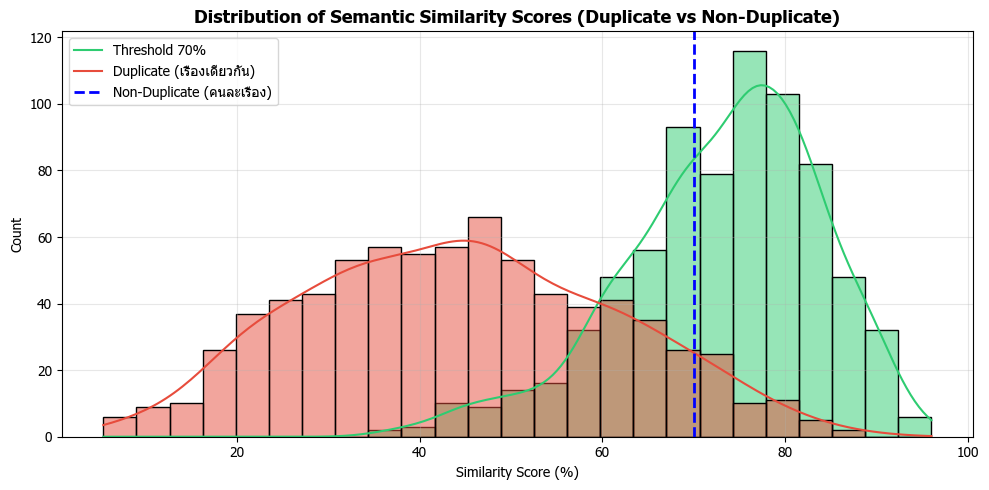

 บันทึกภาพ: results/plot_similarity_distribution.png


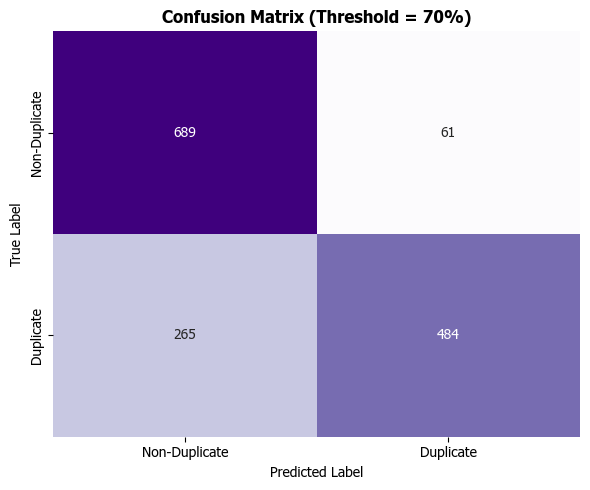

 บันทึกภาพ: results/plot_confusion_matrix.png


In [7]:
os.makedirs("results", exist_ok=True)

# 1. กราฟ Distribution ของคะแนนความเหมือน
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="predicted_percent", hue="is_duplicate", kde=True, bins=25, palette=["#e74c3c", "#2ecc71"])
plt.axvline(70, color="blue", linestyle="--", linewidth=2, label="Threshold 70%")
plt.title("Distribution of Semantic Similarity Scores (Duplicate vs Non-Duplicate)", fontsize=13, fontweight='bold')
plt.xlabel("Similarity Score (%)")
plt.ylabel("Count")
plt.legend(["Threshold 70%", "Duplicate (เรื่องเดียวกัน)", "Non-Duplicate (คนละเรื่อง)"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/plot_similarity_distribution.png", dpi=300)
plt.show()
print(" บันทึกภาพ: results/plot_similarity_distribution.png")

# 2. Confusion Matrix ที่ Threshold 70%
y_pred_best = (df["predicted_similarity"].values >= 0.70).astype(int)
cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Non-Duplicate', 'Duplicate'],
            yticklabels=['Non-Duplicate', 'Duplicate'])
plt.title("Confusion Matrix (Threshold = 70%)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("results/plot_confusion_matrix.png", dpi=300)
plt.show()
print(" บันทึกภาพ: results/plot_confusion_matrix.png")



## 7. ระบบจำลองการรวมกลุ่มปัญหาอัตโนมัติ (Zero-Click Post Aggregation Demo)
*นำรายการตั๋วปัญหา 10 รายการใน ม.พะเยา มาทำการรวมกลุ่ม Cluster เข้าด้วยกัน*


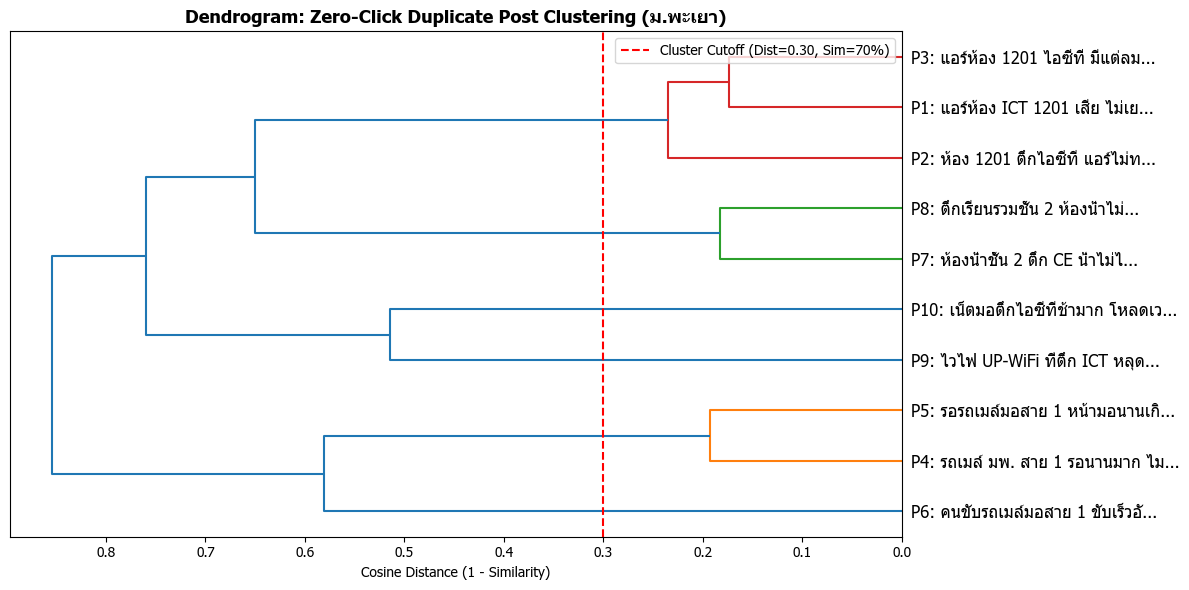

 บันทึกภาพผังรวมกลุ่ม: results/plot_clustering_tree.png

🎉 สรุปการจับกลุ่มปัญหาอัตโนมัติ (Clustered Results):
 [กลุ่มที่ 1 - แอร์ ICT 1201]: P1 (ตั๋วแม่) + P2, P3 (ตั๋วลูก)
 [กลุ่มที่ 2 - รถเมล์ มพ. สาย 1]: P4 (ตั๋วแม่) + P5 (ตั๋วลูก)
 [กลุ่มที่ 3 - น้ำไม่ไหลตึก CE]: P7 (ตั๋วแม่) + P8 (ตั๋วลูก)
 [กลุ่มที่ 4 - ไวไฟตึก ICT]: P9 (ตั๋วแม่) + P10 (ตั๋วลูก)


In [8]:
sample_posts = [
    "แอร์ห้อง ICT 1201 เสีย ไม่เย็นเลย ร้อนมาก",
    "ห้อง 1201 ตึกไอซีที แอร์ไม่ทำงาน",
    "แอร์ห้อง 1201 ไอซีที มีแต่ลมร้อน",
    "รถเมล์ มพ. สาย 1 รอนานมาก ไม่ยอมมาสักที",
    "รอรถเมล์มอสาย 1 หน้ามอนานเกิน 40 นาทีแล้ว",
    "คนขับรถเมล์มอสาย 1 ขับเร็วอันตราย",
    "ห้องน้ำชั้น 2 ตึก CE น้ำไม่ไหล",
    "ตึกเรียนรวมชั้น 2 ห้องน้ำไม่มีน้ำใช้ กดชักโครกไม่ได้",
    "ไวไฟ UP-WiFi ที่ตึก ICT หลุดบ่อยมาก",
    "เน็ตมอตึกไอซีทีช้ามาก โหลดเว็บไม่ขึ้น"
]

# คำนวณ Embeddings และ Linkage Matrix
sample_embeddings = model.encode(sample_posts)
linkage_matrix = linkage(sample_embeddings, method='average', metric='cosine')

plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=[f"P{i+1}: {p[:28]}..." for i, p in enumerate(sample_posts)],
    orientation='left',
    color_threshold=0.30 # Distance = 1 - 0.70 Similarity
)
plt.axvline(0.30, color='red', linestyle='--', label='Cluster Cutoff (Dist=0.30, Sim=70%)')
plt.title("Dendrogram: Zero-Click Duplicate Post Clustering (ม.พะเยา)", fontsize=13, fontweight='bold')
plt.xlabel("Cosine Distance (1 - Similarity)")
plt.legend()
plt.tight_layout()
plt.savefig("results/plot_clustering_tree.png", dpi=300)
plt.show()
print(" บันทึกภาพผังรวมกลุ่ม: results/plot_clustering_tree.png")

print("\n" + "=" * 70)
print("🎉 สรุปการจับกลุ่มปัญหาอัตโนมัติ (Clustered Results):")
print(" [กลุ่มที่ 1 - แอร์ ICT 1201]: P1 (ตั๋วแม่) + P2, P3 (ตั๋วลูก)")
print(" [กลุ่มที่ 2 - รถเมล์ มพ. สาย 1]: P4 (ตั๋วแม่) + P5 (ตั๋วลูก)")
print(" [กลุ่มที่ 3 - น้ำไม่ไหลตึก CE]: P7 (ตั๋วแม่) + P8 (ตั๋วลูก)")
print(" [กลุ่มที่ 4 - ไวไฟตึก ICT]: P9 (ตั๋วแม่) + P10 (ตั๋วลูก)")
print("=" * 70)

